In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, make_scorer, mean_squared_error, explained_variance_score
import matplotlib.dates as mdates
plt.rcParams['figure.figsize'] = (10, 5)
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')

In [7]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

plotly    : 5.24.1
sklearn   : 1.5.1
pandas    : 2.2.2
seaborn   : 0.13.2
tensorflow: 2.19.0
keras     : 3.10.0
numpy     : 1.26.4
matplotlib: 3.9.2



In [8]:
sns.set_style('darkgrid')

In [9]:
data = pd.read_csv('C:/Users/conta/OneDrive/Desktop/Series_Temporais_isp/BaseDPEvolucaoMensalCisp.csv', encoding='latin1', sep=';')

In [10]:
df = data[['mes_ano', 'registro_ocorrencias']]

In [11]:
df['mes_ano'] = df['mes_ano'].str.replace('m', '/')
df['mes_ano'] = pd.to_datetime(df['mes_ano'], format='%Y/%m')

In [12]:
df = df.groupby('mes_ano', as_index=False)['registro_ocorrencias'].sum()

In [13]:
df = df.set_index('mes_ano')

In [14]:
df['registro_ocorrencias'].astype('float32')

mes_ano
2003-01-01    44793.0
2003-02-01    45403.0
2003-03-01    45417.0
2003-04-01    44184.0
2003-05-01    45572.0
               ...   
2024-12-01    76987.0
2025-01-01    81562.0
2025-02-01    80306.0
2025-03-01    84129.0
2025-04-01    75761.0
Name: registro_ocorrencias, Length: 268, dtype: float32

<Axes: xlabel='mes_ano'>

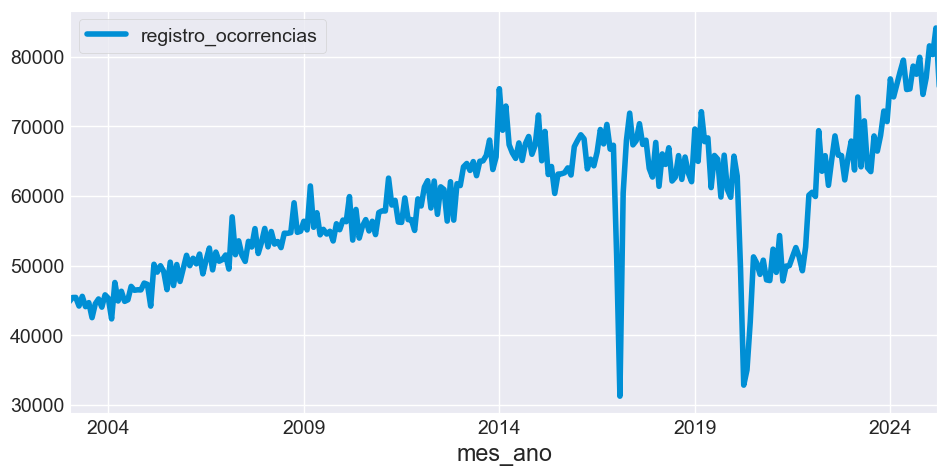

In [15]:
df.plot()

In [16]:
train_size = int(len(df) * 0.8)
test_size = len(df) - train_size

In [17]:
train, test = df.iloc[0:train_size], df.iloc[train_size:len(df)]

In [18]:
print('Tamanho de Treino:', len(train))
print('Tamanho de Teste:', len(test))

Tamanho de Treino: 214
Tamanho de Teste: 54


In [19]:
scaler_target = MinMaxScaler()

In [20]:
train['registro_ocorrencias'] = scaler_target.fit_transform(train['registro_ocorrencias'].to_numpy().reshape(-1, 1))

In [21]:
test['registro_ocorrencias'] = scaler_target.transform(test[['registro_ocorrencias']])

In [22]:
train.tail()

,registro_ocorrencias
mes_ano,
2020-06-01,0.241805
2020-07-01,0.453025
2020-08-01,0.432785
2020-09-01,0.396201
2020-10-01,0.442384


In [23]:
test.head()

,registro_ocorrencias
mes_ano,
2020-11-01,0.378271
2020-12-01,0.376030
2021-01-01,0.478154
2021-02-01,0.402676
2021-03-01,0.522390


In [24]:
def createDataset(X, y, time_steps):
    
    Xs, ys = [], []
    
    for i in range(len(X) - time_steps):
        data = X.iloc[i:(i + time_steps)].values
        Xs.append(data)        
        ys.append(y.iloc[i + time_steps])
        
    return np.array(Xs), np.array(ys)

In [25]:
time_steps = 3

In [26]:
X_train, y_train = createDataset(train, train.registro_ocorrencias, time_steps)

In [27]:
X_test, y_test = createDataset(test, test.registro_ocorrencias, time_steps)

In [28]:
modelo_lstm = tf.keras.Sequential()
modelo_lstm.add(tf.keras.layers.LSTM(units = 128, input_shape = (X_train.shape[1], X_train.shape[2])))
modelo_lstm.add(tf.keras.layers.Dropout(rate = 0.2))
modelo_lstm.add(tf.keras.layers.Dense(units = 1))

In [29]:
modelo_lstm.compile(loss = 'mse', optimizer = 'adam')

In [30]:
modelo_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,689 (260.50 KB)

 Trainable params: 66,689 (260.50 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
%%time
modelo_lstm_history = modelo_lstm.fit(X_train, 
                                      y_train,
                                      epochs = 100,
                                      batch_size = 32,
                                      validation_split = 0.1,
                                      shuffle = False)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.2597 - val_loss: 0.2890
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1431 - val_loss: 0.1545
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0593 - val_loss: 0.0652
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0113 - val_loss: 0.0390
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0105 - val_loss: 0.0575
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0260 - val_loss: 0.0511
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0188 - val_loss: 0.0394
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0098 - val_loss: 0.0379
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0084 - val_loss: 0.0379
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0076 - val_loss: 0.0380
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0073 - val_loss: 0.0391
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0088 - val_lo

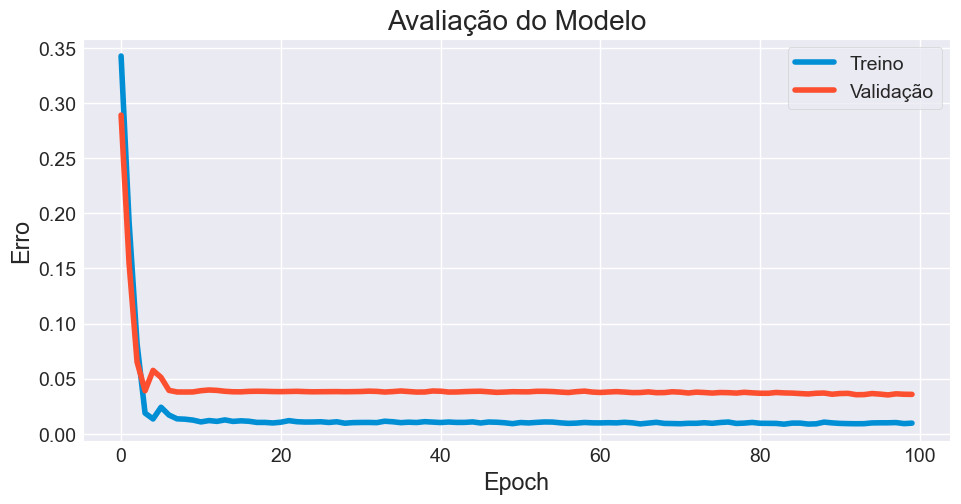

In [32]:
plt.plot(modelo_lstm_history.history['loss'])
plt.plot(modelo_lstm_history.history['val_loss'])
plt.title('Avaliação do Modelo')
plt.ylabel('Erro')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'], loc = 'upper right')
plt.show()

In [33]:
y_pred = modelo_lstm.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


In [34]:
y_train_inv = scaler_target.inverse_transform(y_train.reshape(1, -1)).flatten()
y_test_inv = scaler_target.inverse_transform(y_test.reshape(1, -1)).flatten()
y_pred_inv = scaler_target.inverse_transform(y_pred.reshape(1, -1)).flatten()

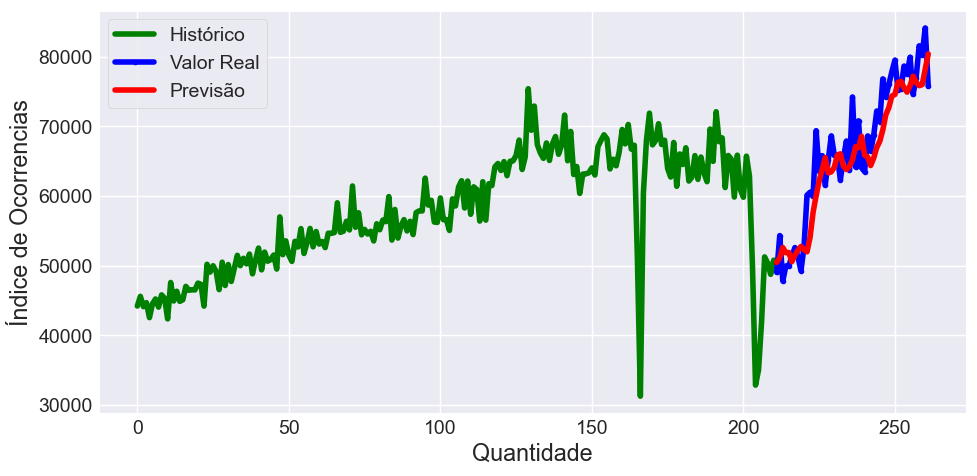

In [35]:
plt.plot(np.arange(0, len(y_train)), 
         y_train_inv, 
         color = 'green', 
         label = "Histórico")

plt.plot(np.arange(len(y_train), 
                   len(y_train) + len(y_test)), 
         y_test_inv, 
         color = 'blue', 
         marker = '.', 
         label = "Valor Real")

plt.plot(np.arange(len(y_train), 
                   len(y_train) + len(y_test)), 
         y_pred_inv, 
         color = 'red', 
         label = "Previsão")

plt.ylabel('Índice de Ocorrencias')
plt.xlabel('Quantidade')
plt.legend()
plt.show();

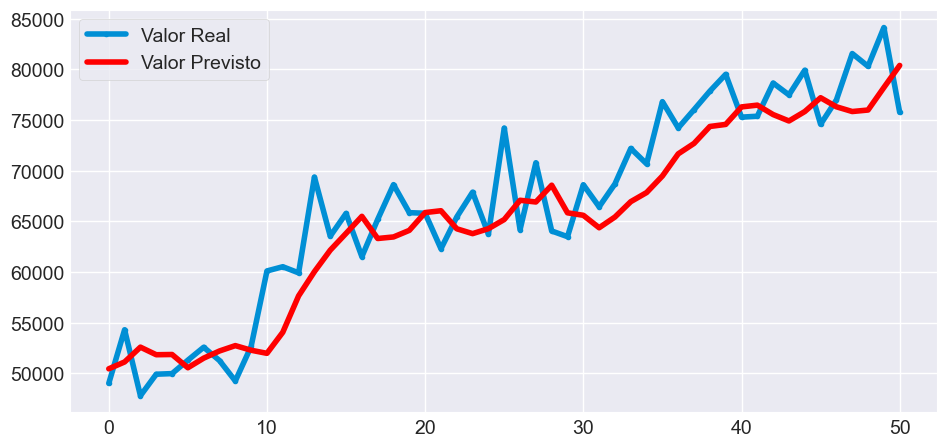

In [36]:
plt.plot(y_test_inv, marker = '.', label = "Valor Real")
plt.plot(y_pred_inv, color = 'red', label = "Valor Previsto")
plt.legend()
plt.show();

In [37]:
def mda(actual: np.ndarray, predicted: np.ndarray):
    return np.mean((np.sign(actual[1:] - actual[:-1]) == np.sign(predicted[1:] - predicted[:-1])).astype(int))

In [38]:
MDA_lstm = mda(y_test_inv, y_pred_inv)
print('MDA:', MDA_lstm)

MAE_lstm = mean_absolute_error(y_test_inv, y_pred_inv)
print('MAE:', MAE_lstm)

MSE_lstm = mean_squared_error(y_test_inv, y_pred_inv)
print('MSE:', MSE_lstm)

RMSE_lstm = mean_squared_error(y_test_inv, y_pred_inv, squared = False)
print('RMSE:', RMSE_lstm)

EVS_lstm = explained_variance_score(y_test_inv, y_pred_inv)
print('EVS Score:', EVS_lstm)

MDA: 0.4
MAE: 3300.7966452205887
MSE: 15565635.640914923
RMSE: 3945.3308658355795
EVS Score: 0.8691887774908134
